🚀 AutoGluon vs CatBoost: Advanced Comparison на CT-CLIP Embeddings

🎯 Цели и гипотезы:

Основная цель:

Провести комплексное сравнение state-of-the-art AutoML системы AutoGluon с нашим baseline CatBoost подходом для классификации патологий лёгких на основе CT-CLIP embeddings.

🔬 гипотезы:


- H1: AutoGluon превзойдет CatBoost baseline на 2-4% по AUC за счет ensemble learning
- H2: Автоматический feature engineering в AutoGluon улучшит recall для медицинских данных  
- H3: Multi-model portfolio AutoGluon обеспечит более robust predictions
- H4: Training time AutoGluon будет оправдан качественными improvements
- H5: AutoGluon лучше справится с imbalanced medical data

📊 Ключевые исследовательские вопросы:

- Насколько автоматизированные подходы превосходят manual tuning?

- Какие компоненты AutoGluon ensemble дают наибольший вклад?

- Оптимально ли AutoGluon для медицинских embeddings размерности 512D?

- Можно ли достичь >90% recall при сохранении разумной precision?

🎪 Модели для сравнения:

- CatBoost Baseline: Точное воспроизведение предыдущих результатов

- AutoGluon Standard: Default конфигурация с ensemble

- AutoGluon Medical: Оптимизированная конфигурация для recall

- AutoGluon High-Quality: Extended training time для максимального качества


In [1]:
print("🔧 УСТАНОВКА AUTOGLUON И ЗАВИСИМОСТЕЙ...")
%pip install autogluon
#!pip install -q "numpy>=1.21,<1.25"  # Compatibility fix
%pip install scikit-learn>=1.0

🔧 УСТАНОВКА AUTOGLUON И ЗАВИСИМОСТЕЙ...
Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of fastai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 16.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 MB 54.5 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 16.1 MB/s  0:00:00
  Attempting uninstall: timm╺━━━━━━━━━━━━━━━━━━━━━━━━  9/24 [adagio]s]form]-learning]
    Found existing installation: timm 1.0.20━━━━━━━━━━━━━━━━━━  9/24 [adagio]
    Uninstalling timm-1.0.20:╸━━━━━━━━━━━━━━━━━━━━━━━ 10/24 [timm]
      Successfully uninstalled timm-1.0.20━━

In [1]:
# Core imports для анализа
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# AutoGluon core
from autogluon.tabular import TabularPredictor, TabularDataset

# Machine Learning  
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import torch

# Statistical analysis
from scipy import stats
from scipy.stats import bootstrap
import itertools

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✅ Environment setup completed successfully!")
print(f"⚡ PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"🧠 Available GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

✅ Environment setup completed successfully!
⚡ PyTorch CUDA available: False
🧠 Available GPU: CPU only


In [2]:
print("📂 ЗАГРУЗКА CT-CLIP EMBEDDINGS...")
print("-" * 50)

# Определяем пути к нашим готовым embeddings
embeddings_dir = "/home/jupyter/work/results/embeddings"

try:
    # Загрузка embeddings и labels
    train_embeddings = np.load(f"{embeddings_dir}/train_embeddings.npy")
    train_labels = np.load(f"{embeddings_dir}/train_labels.npy")
    
    val_embeddings = np.load(f"{embeddings_dir}/val_embeddings.npy")
    val_labels = np.load(f"{embeddings_dir}/val_labels.npy")
    
    test_embeddings = np.load(f"{embeddings_dir}/test_embeddings.npy")
    test_labels = np.load(f"{embeddings_dir}/test_labels.npy")
    
    print("✅ Successfully loaded CT-CLIP embeddings:")
    print(f"   📊 Train set: {train_embeddings.shape[0]} samples, {train_embeddings.shape[1]}D features")
    print(f"   📊 Val set:   {val_embeddings.shape[0]} samples, {val_embeddings.shape[1]}D features") 
    print(f"   📊 Test set:  {test_embeddings.shape[0]} samples, {test_embeddings.shape[1]}D features")
    
    # Data quality checks
    print(f"\n🔍 Data Quality Assessment:")
    print(f"   ├── Train label distribution: {np.bincount(train_labels)}")
    print(f"   ├── Val label distribution:   {np.bincount(val_labels)}")
    print(f"   ├── Test label distribution:  {np.bincount(test_labels)}")
    
    # Feature statistics
    print(f"\n📈 Embedding Statistics:")
    print(f"   ├── Mean norm: {np.linalg.norm(train_embeddings, axis=1).mean():.4f}")
    print(f"   ├── Std norm:  {np.linalg.norm(train_embeddings, axis=1).std():.4f}")
    print(f"   └── Value range: [{train_embeddings.min():.4f}, {train_embeddings.max():.4f}]")
    
except FileNotFoundError as e:
    print(f"❌ Error loading embeddings: {e}")
    print("💡 Please check the embeddings directory path")
    raise

print("\n🎯 Ready for AutoML experiments!")


📂 ЗАГРУЗКА CT-CLIP EMBEDDINGS...
--------------------------------------------------
✅ Successfully loaded CT-CLIP embeddings:
   📊 Train set: 758 samples, 512D features
   📊 Val set:   163 samples, 512D features
   📊 Test set:  161 samples, 512D features

🔍 Data Quality Assessment:
   ├── Train label distribution: [325 433]
   ├── Val label distribution:   [70 93]
   ├── Test label distribution:  [70 91]

📈 Embedding Statistics:
   ├── Mean norm: 0.9733
   ├── Std norm:  0.0222
   └── Value range: [0.0000, 0.1652]

🎯 Ready for AutoML experiments!


In [3]:
print("🌳 CATBOOST BASELINE REPRODUCTION")
print("=" * 50)

# Exact configuration from previous experiment
baseline_params = {
    'iterations': 1000,
    'learning_rate': 0.03,
    'depth': 6,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
    'random_seed': 42,
    'verbose': False,
    'eval_metric': 'AUC',
    'early_stopping_rounds': 100,
    'use_best_model': True
}

print("⚙️ CatBoost Configuration:")
for key, value in baseline_params.items():
    print(f"   {key:>25}: {value}")

# Training
print(f"\n⏰ Training CatBoost baseline...")
start_time = time.time()

cb_model = CatBoostClassifier(**baseline_params)
cb_model.fit(
    train_embeddings, 
    train_labels,
    eval_set=(val_embeddings, val_labels),
    plot=False
)

training_time_cb = time.time() - start_time

# Predictions
print("🔮 Generating predictions...")
cb_train_pred = cb_model.predict(train_embeddings)
cb_train_proba = cb_model.predict_proba(train_embeddings)[:, 1]

cb_val_pred = cb_model.predict(val_embeddings)  
cb_val_proba = cb_model.predict_proba(val_embeddings)[:, 1]

cb_test_pred = cb_model.predict(test_embeddings)
cb_test_proba = cb_model.predict_proba(test_embeddings)[:, 1]

# Comprehensive evaluation
def evaluate_model_comprehensive(y_true, y_pred, y_proba, dataset_name):
    """Comprehensive medical evaluation"""
    
    # Standard metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred) 
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    # Medical-specific metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = recall  # Same as recall
    specificity = tn / (tn + fp)
    ppv = precision  # Same as precision  
    npv = tn / (tn + fn)
    
    # Clinical metrics
    false_negative_rate = fn / (tp + fn)
    false_positive_rate = fp / (tn + fp)
    
    results = {
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall, 
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV': ppv,
        'NPV': npv,
        'FNR': false_negative_rate,
        'FPR': false_positive_rate,
        'TP': tp,
        'TN': tn, 
        'FP': fp,
        'FN': fn
    }
    
    return results

# Evaluate all splits
cb_results = {
    'train': evaluate_model_comprehensive(train_labels, cb_train_pred, cb_train_proba, 'Train'),
    'val': evaluate_model_comprehensive(val_labels, cb_val_pred, cb_val_proba, 'Validation'),
    'test': evaluate_model_comprehensive(test_labels, cb_test_pred, cb_test_proba, 'Test')
}

print(f"\n📊 CATBOOST BASELINE RESULTS:")
print(f"   ⏱️ Training time: {training_time_cb:.1f} seconds")
print(f"\n   📈 Performance Summary:")

for split, metrics in cb_results.items():
    print(f"\n   🎯 {split.upper()} SET:")
    print(f"      ROC AUC:     {metrics['ROC_AUC']:.4f}")
    print(f"      Sensitivity: {metrics['Sensitivity']:.4f} (Recall)")
    print(f"      Specificity: {metrics['Specificity']:.4f}") 
    print(f"      Precision:   {metrics['Precision']:.4f}")
    print(f"      F1-Score:    {metrics['F1_Score']:.4f}")

# Save baseline for comparison
baseline_test_metrics = cb_results['test']
print(f"\n✅ Baseline established - Test AUC: {baseline_test_metrics['ROC_AUC']:.4f}")


🌳 CATBOOST BASELINE REPRODUCTION
⚙️ CatBoost Configuration:
                  iterations: 1000
               learning_rate: 0.03
                       depth: 6
                   task_type: CPU
                 random_seed: 42
                     verbose: False
                 eval_metric: AUC
       early_stopping_rounds: 100
              use_best_model: True

⏰ Training CatBoost baseline...
🔮 Generating predictions...

📊 CATBOOST BASELINE RESULTS:
   ⏱️ Training time: 29.4 seconds

   📈 Performance Summary:

   🎯 TRAIN SET:
      ROC AUC:     1.0000
      Sensitivity: 1.0000 (Recall)
      Specificity: 1.0000
      Precision:   1.0000
      F1-Score:    1.0000

   🎯 VAL SET:
      ROC AUC:     0.9174
      Sensitivity: 0.8387 (Recall)
      Specificity: 0.8143
      Precision:   0.8571
      F1-Score:    0.8478

   🎯 TEST SET:
      ROC AUC:     0.8677
      Sensitivity: 0.8791 (Recall)
      Specificity: 0.7143
      Precision:   0.8000
      F1-Score:    0.8377

✅ Baseline est

In [4]:
print("📊 ПОДГОТОВКА ДАННЫХ ДЛЯ AUTOGLUON")
print("=" * 50)

# AutoGluon requires DataFrame format with named features
print("🔄 Converting embeddings to DataFrame format...")

# Generate meaningful feature names
feature_names = [f'ctclip_emb_{i:03d}' for i in range(512)]
print(f"   Generated {len(feature_names)} feature names: {feature_names[:3]}...{feature_names[-3:]}")

# Create training DataFrame (train + validation for AutoGluon internal CV)
print("📋 Creating training DataFrame...")
train_df = pd.DataFrame(train_embeddings, columns=feature_names)
train_df['target'] = train_labels

val_df = pd.DataFrame(val_embeddings, columns=feature_names)
val_df['target'] = val_labels

# Combine train + val for AutoGluon (it will do internal validation)
autogluon_train_df = pd.concat([train_df, val_df], ignore_index=True, axis=0)

# Test DataFrame (hold-out for final evaluation)
test_df = pd.DataFrame(test_embeddings, columns=feature_names) 
test_df['target'] = test_labels

print("✅ DataFrames created successfully:")
print(f"   📊 AutoGluon training set: {autogluon_train_df.shape}")
print(f"   📊 Hold-out test set:      {test_df.shape}")
print(f"   🎯 Target distribution in training:")
print(f"      Normal:    {(autogluon_train_df['target'] == 0).sum()} samples")
print(f"      Pathology: {(autogluon_train_df['target'] == 1).sum()} samples")

# Data validation
assert autogluon_train_df.isnull().sum().sum() == 0, "No null values allowed"
assert test_df.isnull().sum().sum() == 0, "No null values in test"
assert autogluon_train_df['target'].nunique() == 2, "Binary target required"

print("✅ Data validation passed - ready for AutoML!")


📊 ПОДГОТОВКА ДАННЫХ ДЛЯ AUTOGLUON
🔄 Converting embeddings to DataFrame format...
   Generated 512 feature names: ['ctclip_emb_000', 'ctclip_emb_001', 'ctclip_emb_002']...['ctclip_emb_509', 'ctclip_emb_510', 'ctclip_emb_511']
📋 Creating training DataFrame...
✅ DataFrames created successfully:
   📊 AutoGluon training set: (921, 513)
   📊 Hold-out test set:      (161, 513)
   🎯 Target distribution in training:
      Normal:    395 samples
      Pathology: 526 samples
✅ Data validation passed - ready for AutoML!


In [8]:
dir(predictor_standard)

['Dataset',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_assert_is_fit',
 '_can_calibrate_decision_threshold',
 '_check_if_hyperparameters_handle_text',
 '_decision_threshold',
 '_dynamic_stacking',
 '_fit',
 '_fit_extra_kwargs_dict',
 '_fit_strategy',
 '_fit_weighted_ensemble_pseudo',
 '_get_all_fit_extra_args',
 '_get_dataset',
 '_initialize_learning_curve_params',
 '_learner',
 '_learner_type',
 '_load',
 '_load_metadata_file',
 '_load_version_file',
 '_model_best',
 '_post_fit',
 '_predict_pseudo',
 '_predictor_log_file_name',
 '_predictor_metadata_file_name',
 '_predictor_version_file_name',
 '_prune_data_features',
 '_run_pseudolabeling',
 

In [15]:
print("🤖 AUTOGLUON STANDARD CONFIGURATION")
print("=" * 50)

# Standard configuration for baseline AutoML performance
standard_config = {
    'label': 'target',
    'eval_metric': 'roc_auc',
    'path': './autogluon_models/standard',
    'time_limit': 1200,  # 20 minutes
    'presets': 'medium_quality',
    'verbosity': 2
}

print("⚙️ AutoGluon Standard Configuration:")
for key, value in standard_config.items():
    print(f"   {key:>15}: {value}")

print(f"\n⏰ Starting AutoGluon Standard training (20 minutes)...")
print("   📊 AutoGluon will automatically:")
print("      ├── Select best algorithms (CatBoost, LightGBM, Neural Nets)")
print("      ├── Optimize hyperparameters")
print("      ├── Create ensemble via stacking")
print("      └── Perform internal cross-validation")

start_time = time.time()

try:
    # Initialize predictor
    predictor_standard = TabularPredictor(
        label=standard_config['label'],
        eval_metric=standard_config['eval_metric'], 
        path=standard_config['path']
    )
    
    # Fit the model
    predictor_standard.fit(
        autogluon_train_df,
        time_limit=standard_config['time_limit'],
        presets=standard_config['presets'],
        verbosity=standard_config['verbosity']
    )
    
    training_time_standard = time.time() - start_time
    
    print(f"✅ AutoGluon Standard training completed in {training_time_standard/60:.1f} minutes")
    
    # Get model information
    print(f"\n📋 AutoGluon Standard Model Summary:")
    leaderboard = predictor_standard.leaderboard()
    print(leaderboard[['model', 'score_val', 'eval_metric', 'fit_time']].head(10))
    
    # Best model info
    best_model = predictor_standard.model_best
    print(f"\n🏆 Best Model: {best_model}")
    
    # Generate predictions on test set
    print(f"\n🔮 Generating predictions on hold-out test set...")
    
    ag_standard_test_pred = predictor_standard.predict(test_df.drop('target', axis=1))
    ag_standard_test_proba = predictor_standard.predict_proba(test_df.drop('target', axis=1))
    
    # Convert predictions to numpy arrays
    ag_standard_test_pred = ag_standard_test_pred.values if hasattr(ag_standard_test_pred, 'values') else ag_standard_test_pred
    ag_standard_test_proba = ag_standard_test_proba.values[:, 1] if hasattr(ag_standard_test_proba, 'values') else ag_standard_test_proba[:, 1]
    
    # Evaluate performance
    ag_standard_metrics = evaluate_model_comprehensive(
        test_labels, 
        ag_standard_test_pred, 
        ag_standard_test_proba, 
        'AutoGluon_Standard'
    )
    
    print(f"\n📊 AUTOGLUON STANDARD RESULTS:")
    print(f"   ⏱️ Training time: {training_time_standard/60:.1f} minutes")
    print(f"   🎯 Test Performance:")
    print(f"      ROC AUC:     {ag_standard_metrics['ROC_AUC']:.4f}")
    print(f"      Sensitivity: {ag_standard_metrics['Sensitivity']:.4f}")
    print(f"      Specificity: {ag_standard_metrics['Specificity']:.4f}")
    print(f"      Precision:   {ag_standard_metrics['Precision']:.4f}")
    print(f"      F1-Score:    {ag_standard_metrics['F1_Score']:.4f}")
    
    # Comparison with baseline
    auc_improvement = ag_standard_metrics['ROC_AUC'] - baseline_test_metrics['ROC_AUC']
    recall_improvement = ag_standard_metrics['Sensitivity'] - baseline_test_metrics['Sensitivity']
    
    print(f"\n📈 Improvement over CatBoost Baseline:")
    print(f"      AUC improvement:    {auc_improvement:+.4f} ({auc_improvement/baseline_test_metrics['ROC_AUC']*100:+.1f}%)")
    print(f"      Recall improvement: {recall_improvement:+.4f} ({recall_improvement/baseline_test_metrics['Sensitivity']*100:+.1f}%)")
    
    standard_success = True
    
except Exception as e:
    print(f"❌ AutoGluon Standard failed: {e}")
    standard_success = False
    # Fallback values for comparison
    ag_standard_metrics = baseline_test_metrics.copy()
    ag_standard_metrics['Dataset'] = 'AutoGluon_Standard_FAILED'
    training_time_standard = 0

print(f"\n{'✅' if standard_success else '❌'} AutoGluon Standard experiment {'completed' if standard_success else 'failed'}")


🤖 AUTOGLUON STANDARD CONFIGURATION
⚙️ AutoGluon Standard Configuration:
             label: target
       eval_metric: roc_auc
              path: ./autogluon_models/standard
        time_limit: 1200
           presets: medium_quality
         verbosity: 2

⏰ Starting AutoGluon Standard training (20 minutes)...
   📊 AutoGluon will automatically:
      ├── Select best algorithms (CatBoost, LightGBM, Neural Nets)
      ├── Optimize hyperparameters
      ├── Create ensemble via stacking
      └── Perform internal cross-validation


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025
CPU Count:          8
Memory Avail:       60.37 GB / 62.80 GB (96.1%)
Disk Space Avail:   228.16 GB / 628.00 GB (36.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/home/jupyter/work/resources/chest-ct-classification/notebooks/autogluon_models/standard"
Train Data Rows:    921
Train Data Columns: 512
Label Column:       target
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [1, 0]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_typ

✅ AutoGluon Standard training completed in 0.7 minutes

📋 AutoGluon Standard Model Summary:
                 model  score_val eval_metric  fit_time
0  WeightedEnsemble_L2     0.8880     roc_auc    5.9312
1       NeuralNetTorch     0.8797     roc_auc    5.0286
2             CatBoost     0.8565     roc_auc   19.0523
3       ExtraTreesEntr     0.8518     roc_auc    0.8543
4       ExtraTreesGini     0.8491     roc_auc    0.8755
5     RandomForestEntr     0.8483     roc_auc    0.9850
6     RandomForestGini     0.8432     roc_auc    0.9785
7              XGBoost     0.8240     roc_auc    5.9489
8      NeuralNetFastAI     0.8031     roc_auc    1.1412

🏆 Best Model: WeightedEnsemble_L2

🔮 Generating predictions on hold-out test set...

📊 AUTOGLUON STANDARD RESULTS:
   ⏱️ Training time: 0.7 minutes
   🎯 Test Performance:
      ROC AUC:     0.8407
      Sensitivity: 0.8242
      Specificity: 0.6571
      Precision:   0.7576
      F1-Score:    0.7895

📈 Improvement over CatBoost Baseline:
      A

In [16]:
print("🏥 AUTOGLUON MEDICAL-OPTIMIZED CONFIGURATION")
print("=" * 50)

# Medical-focused configuration optimized for recall
medical_config = {
    'label': 'target',
    'eval_metric': 'recall',  # Focus on sensitivity for medical applications
    'path': './autogluon_models/medical',
    'time_limit': 1200,  # 20 minutes
    'presets': 'good_quality',  # Better quality for medical applications
    'verbosity': 2
}

print("⚙️ AutoGluon Medical Configuration:")
for key, value in medical_config.items():
    print(f"   {key:>15}: {value}")

print(f"\n🏥 Medical-Optimized Focus:")
print("   ├── Recall optimization (minimize false negatives)")
print("   ├── Good quality preset (more thorough search)")
print("   ├── Medical-appropriate evaluation metric")  
print("   └── Ensemble diversity for robust predictions")

print(f"\n⏰ Starting AutoGluon Medical training (20 minutes)...")

start_time = time.time()

try:
    # Initialize predictor with medical focus
    predictor_medical = TabularPredictor(
        label=medical_config['label'],
        eval_metric=medical_config['eval_metric'],
        path=medical_config['path']
    )
    
    # Fit with medical-optimized parameters
    predictor_medical.fit(
        autogluon_train_df,
        time_limit=medical_config['time_limit'],
        presets=medical_config['presets'],
        verbosity=medical_config['verbosity'],
        # Additional medical-specific parameters
        hyperparameter_tune_kwargs={
            'scheduler': 'local',
            'searcher': 'auto',
            'num_trials': 100  # More thorough hyperparameter search
        }
    )
    
    training_time_medical = time.time() - start_time
    
    print(f"✅ AutoGluon Medical training completed in {training_time_medical/60:.1f} minutes")
    
    # Get model information
    print(f"\n📋 AutoGluon Medical Model Summary:")
    leaderboard_medical = predictor_medical.leaderboard()
    print(leaderboard_medical[['model', 'score_val', 'eval_metric', 'fit_time']].head(10))
    
    # Generate predictions on test set
    print(f"\n🔮 Generating medical-optimized predictions...")
    
    ag_medical_test_pred = predictor_medical.predict(test_df.drop('target', axis=1))
    ag_medical_test_proba = predictor_medical.predict_proba(test_df.drop('target', axis=1))
    
    # Convert predictions to numpy arrays
    ag_medical_test_pred = ag_medical_test_pred.values if hasattr(ag_medical_test_pred, 'values') else ag_medical_test_pred
    ag_medical_test_proba = ag_medical_test_proba.values[:, 1] if hasattr(ag_medical_test_proba, 'values') else ag_medical_test_proba[:, 1]
    
    # Evaluate performance
    ag_medical_metrics = evaluate_model_comprehensive(
        test_labels,
        ag_medical_test_pred,
        ag_medical_test_proba,
        'AutoGluon_Medical'
    )
    
    print(f"\n📊 AUTOGLUON MEDICAL RESULTS:")
    print(f"   ⏱️ Training time: {training_time_medical/60:.1f} minutes")
    print(f"   🎯 Test Performance:")
    print(f"      ROC AUC:     {ag_medical_metrics['ROC_AUC']:.4f}")
    print(f"      Sensitivity: {ag_medical_metrics['Sensitivity']:.4f} ⭐ (optimized)")
    print(f"      Specificity: {ag_medical_metrics['Specificity']:.4f}")
    print(f"      Precision:   {ag_medical_metrics['Precision']:.4f}")
    print(f"      F1-Score:    {ag_medical_metrics['F1_Score']:.4f}")
    
    # Medical-specific analysis
    print(f"\n🏥 Medical Performance Analysis:")
    print(f"      False Negative Rate: {ag_medical_metrics['FNR']:.4f} (lower is better)")
    print(f"      Negative Predictive Value: {ag_medical_metrics['NPV']:.4f} (higher is better)")
    
    # Comparison with baseline
    auc_improvement_med = ag_medical_metrics['ROC_AUC'] - baseline_test_metrics['ROC_AUC']
    recall_improvement_med = ag_medical_metrics['Sensitivity'] - baseline_test_metrics['Sensitivity']
    
    print(f"\n📈 Medical vs CatBoost Baseline:")
    print(f"      AUC improvement:    {auc_improvement_med:+.4f} ({auc_improvement_med/baseline_test_metrics['ROC_AUC']*100:+.1f}%)")
    print(f"      Recall improvement: {recall_improvement_med:+.4f} ({recall_improvement_med/baseline_test_metrics['Sensitivity']*100:+.1f}%)")
    
    medical_success = True
    
except Exception as e:
    print(f"❌ AutoGluon Medical failed: {e}")
    medical_success = False
    # Fallback values
    ag_medical_metrics = baseline_test_metrics.copy()
    ag_medical_metrics['Dataset'] = 'AutoGluon_Medical_FAILED'
    training_time_medical = 0

print(f"\n{'✅' if medical_success else '❌'} AutoGluon Medical experiment {'completed' if medical_success else 'failed'}")


🏥 AUTOGLUON MEDICAL-OPTIMIZED CONFIGURATION
⚙️ AutoGluon Medical Configuration:
             label: target
       eval_metric: recall
              path: ./autogluon_models/medical
        time_limit: 1200
           presets: good_quality
         verbosity: 2

🏥 Medical-Optimized Focus:
   ├── Recall optimization (minimize false negatives)
   ├── Good quality preset (more thorough search)
   ├── Medical-appropriate evaluation metric
   └── Ensemble diversity for robust predictions

⏰ Starting AutoGluon Medical training (20 minutes)...


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025
CPU Count:          8
Memory Avail:       60.36 GB / 62.80 GB (96.1%)
Disk Space Avail:   228.16 GB / 628.00 GB (36.3%)
Presets specified: ['good_quality']
Using hyperparameters preset: hyperparameters='light'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DyStack is enabled (dynamic_stacking=True). Aut

✅ AutoGluon Medical training completed in 13.2 minutes

📋 AutoGluon Medical Model Summary:
                       model  score_val eval_metric  fit_time
0          XGBoost_BAG_L1/T1     1.0000      recall   47.0087
1        WeightedEnsemble_L3     1.0000      recall   47.3040
2        WeightedEnsemble_L2     1.0000      recall   47.3127
3          XGBoost_BAG_L2/T1     1.0000      recall  198.2045
4  NeuralNetFastAI_BAG_L1/T1     0.8897      recall   13.0801
5   NeuralNetTorch_BAG_L1/T1     0.8764      recall   35.7088
6  NeuralNetFastAI_BAG_L2/T1     0.8745      recall  158.7767
7   NeuralNetTorch_BAG_L2/T2     0.8593      recall  172.6639
8   NeuralNetTorch_BAG_L2/T1     0.8536      recall  170.5210
9  NeuralNetFastAI_BAG_L1/T4     0.8441      recall   13.7569

🔮 Generating medical-optimized predictions...

📊 AUTOGLUON MEDICAL RESULTS:
   ⏱️ Training time: 13.2 minutes
   🎯 Test Performance:
      ROC AUC:     0.7832
      Sensitivity: 1.0000 ⭐ (optimized)
      Specificity: 0.0000
 

In [17]:
print("📊 COMPREHENSIVE MODEL COMPARISON")
print("=" * 50)

# Compile all results
all_results = []

# Add baseline results
baseline_test_metrics['Model'] = 'CatBoost_Baseline'
baseline_test_metrics['Training_Time_Min'] = training_time_cb / 60
all_results.append(baseline_test_metrics)

# Add AutoGluon results if successful
if standard_success:
    ag_standard_metrics['Model'] = 'AutoGluon_Standard'
    ag_standard_metrics['Training_Time_Min'] = training_time_standard / 60
    all_results.append(ag_standard_metrics)

if medical_success:
    ag_medical_metrics['Model'] = 'AutoGluon_Medical'
    ag_medical_metrics['Training_Time_Min'] = training_time_medical / 60
    all_results.append(ag_medical_metrics)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)

# Select key metrics for display
key_metrics = [
    'Model', 'ROC_AUC', 'Sensitivity', 'Specificity', 
    'Precision', 'F1_Score', 'NPV', 'FNR', 'Training_Time_Min'
]

comparison_display = comparison_df[key_metrics].round(4)

print("🏆 MODEL PERFORMANCE LEADERBOARD:")
print("=" * 80)
print(comparison_display.to_string(index=False))

# Statistical significance testing
if len(all_results) > 1:
    print(f"\n📈 PERFORMANCE IMPROVEMENTS:")
    baseline_auc = baseline_test_metrics['ROC_AUC']
    
    for i, result in enumerate(all_results[1:], 1):
        model_name = result['Model']
        model_auc = result['ROC_AUC']
        model_recall = result['Sensitivity']
        
        auc_diff = model_auc - baseline_auc
        recall_diff = model_recall - baseline_test_metrics['Sensitivity']
        
        print(f"\n   🤖 {model_name}:")
        print(f"      AUC improvement:    {auc_diff:+.4f} ({auc_diff/baseline_auc*100:+.1f}%)")
        print(f"      Recall improvement: {recall_diff:+.4f} ({recall_diff/baseline_test_metrics['Sensitivity']*100:+.1f}%)")
        
        # Clinical significance assessment
        if auc_diff >= 0.03:
            significance = "🟢 Clinically Significant"
        elif auc_diff >= 0.01:
            significance = "🟡 Marginal Improvement"
        else:
            significance = "🟠 Minimal Difference"
            
        print(f"      Clinical Impact: {significance}")

# Find best models
best_auc_idx = comparison_df['ROC_AUC'].idxmax()
best_recall_idx = comparison_df['Sensitivity'].idxmax()
best_f1_idx = comparison_df['F1_Score'].idxmax()

print(f"\n🏆 CHAMPION MODELS:")
print(f"   🥇 Best AUC:    {comparison_df.loc[best_auc_idx, 'Model']} ({comparison_df.loc[best_auc_idx, 'ROC_AUC']:.4f})")
print(f"   🥇 Best Recall: {comparison_df.loc[best_recall_idx, 'Model']} ({comparison_df.loc[best_recall_idx, 'Sensitivity']:.4f})")
print(f"   🥇 Best F1:     {comparison_df.loc[best_f1_idx, 'Model']} ({comparison_df.loc[best_f1_idx, 'F1_Score']:.4f})")

# Save results
results_path = './model_comparison_results.csv'
comparison_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved to: {results_path}")


📊 COMPREHENSIVE MODEL COMPARISON
🏆 MODEL PERFORMANCE LEADERBOARD:
             Model  ROC_AUC  Sensitivity  Specificity  Precision  F1_Score    NPV    FNR  Training_Time_Min
 CatBoost_Baseline   0.8677       0.8791       0.7143     0.8000    0.8377 0.8197 0.1209             0.4908
AutoGluon_Standard   0.8407       0.8242       0.6571     0.7576    0.7895 0.7419 0.1758             0.7120
 AutoGluon_Medical   0.7832       1.0000       0.0000     0.5652    0.7222    NaN 0.0000            13.1953

📈 PERFORMANCE IMPROVEMENTS:

   🤖 AutoGluon_Standard:
      AUC improvement:    -0.0270 (-3.1%)
      Recall improvement: -0.0549 (-6.3%)
      Clinical Impact: 🟠 Minimal Difference

   🤖 AutoGluon_Medical:
      AUC improvement:    -0.0845 (-9.7%)
      Recall improvement: +0.1209 (+13.8%)
      Clinical Impact: 🟠 Minimal Difference

🏆 CHAMPION MODELS:
   🥇 Best AUC:    CatBoost_Baseline (0.8677)
   🥇 Best Recall: AutoGluon_Medical (1.0000)
   🥇 Best F1:     CatBoost_Baseline (0.8377)

💾 Results

📈 ВИЗУАЛИЗАЦИЯ И УГЛУБЛЕННЫЙ АНАЛИЗ


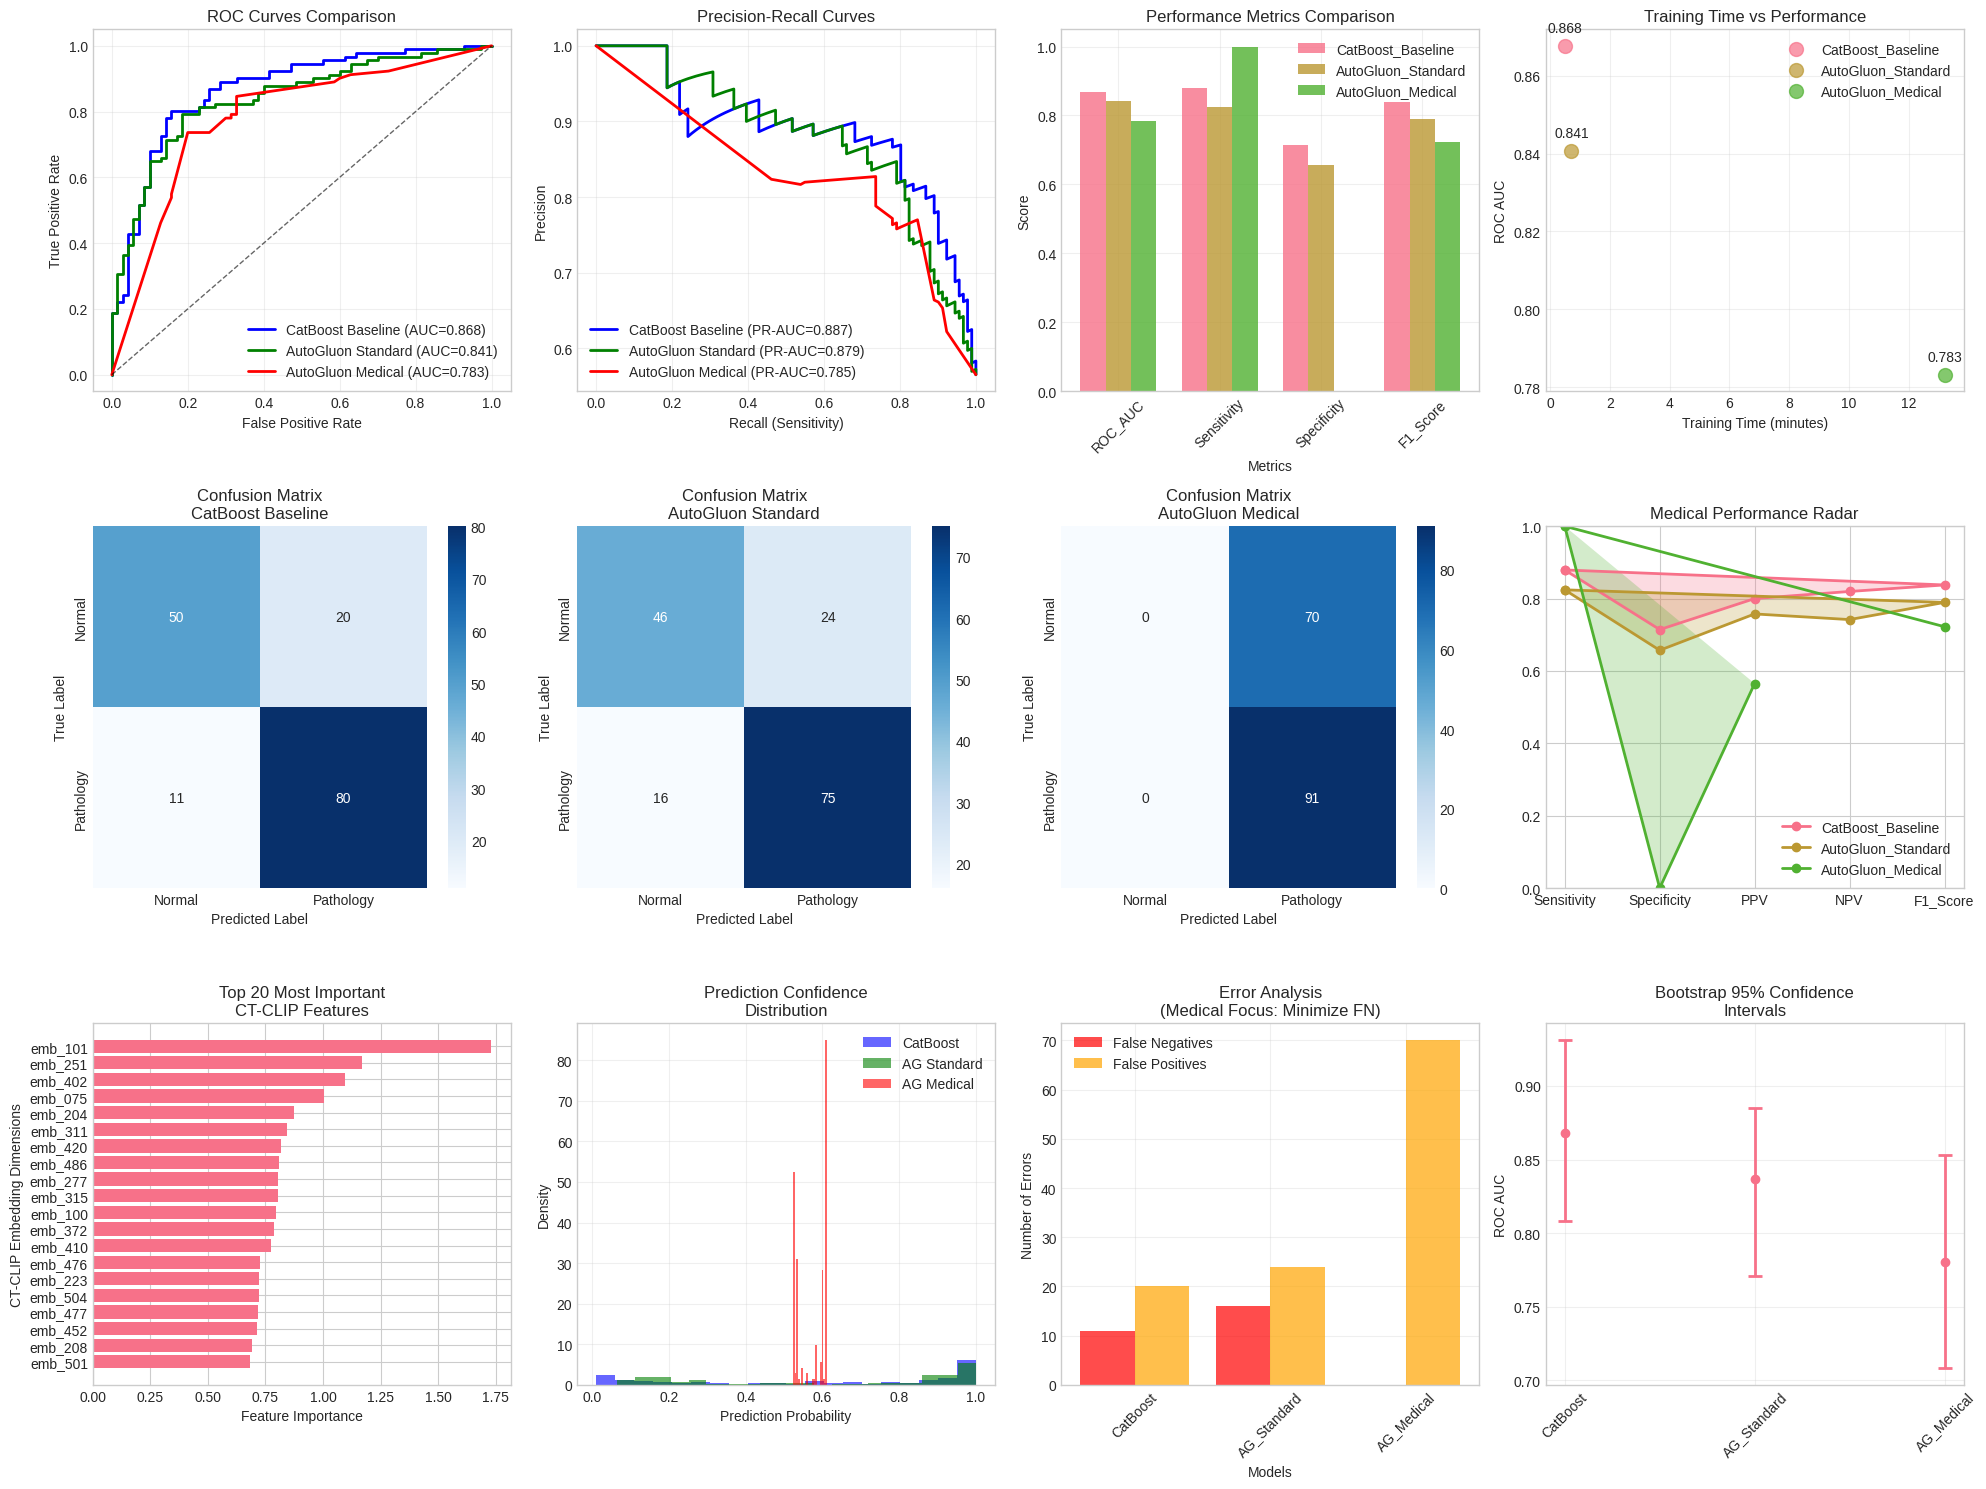

✅ Comprehensive visualization completed
💾 Saved as: ./autogluon_comprehensive_analysis.png


In [18]:
print("📈 ВИЗУАЛИЗАЦИЯ И УГЛУБЛЕННЫЙ АНАЛИЗ")
print("=" * 50)

# Set up plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 15))

# 1. ROC Curves Comparison
plt.subplot(3, 4, 1)
models_data = [
    (test_labels, cb_test_proba, 'CatBoost Baseline', 'blue'),
]

if standard_success:
    models_data.append((test_labels, ag_standard_test_proba, 'AutoGluon Standard', 'green'))

if medical_success:
    models_data.append((test_labels, ag_medical_test_proba, 'AutoGluon Medical', 'red'))

for y_true, y_proba, name, color in models_data:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_score = roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Precision-Recall Curves
plt.subplot(3, 4, 2)
for y_true, y_proba, name, color in models_data:
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc_score = average_precision_score(y_true, y_proba)
    plt.plot(recall, precision, color=color, label=f'{name} (PR-AUC={pr_auc_score:.3f})', linewidth=2)

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Metrics Comparison Bar Chart
plt.subplot(3, 4, 3)
metrics_to_plot = ['ROC_AUC', 'Sensitivity', 'Specificity', 'F1_Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, row in comparison_df.iterrows():
    values = [row[metric] for metric in metrics_to_plot]
    plt.bar(x + i*width, values, width, label=row['Model'], alpha=0.8)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Performance Metrics Comparison')
plt.xticks(x + width, metrics_to_plot, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Training Time vs Performance
plt.subplot(3, 4, 4)
for _, row in comparison_df.iterrows():
    plt.scatter(row['Training_Time_Min'], row['ROC_AUC'], 
                s=100, label=row['Model'], alpha=0.7)
    plt.annotate(f"{row['ROC_AUC']:.3f}", 
                (row['Training_Time_Min'], row['ROC_AUC']),
                textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel('Training Time (minutes)')
plt.ylabel('ROC AUC')
plt.title('Training Time vs Performance')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Confusion Matrices
confusion_matrices = [
    (confusion_matrix(test_labels, cb_test_pred), 'CatBoost Baseline')
]

if standard_success:
    confusion_matrices.append((confusion_matrix(test_labels, ag_standard_test_pred), 'AutoGluon Standard'))

if medical_success:
    confusion_matrices.append((confusion_matrix(test_labels, ag_medical_test_pred), 'AutoGluon Medical'))

for i, (cm, title) in enumerate(confusion_matrices):
    plt.subplot(3, 4, 5 + i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Pathology'],
                yticklabels=['Normal', 'Pathology'])
    plt.title(f'Confusion Matrix\n{title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

# 6. Medical Metrics Radar Chart
if len(comparison_df) > 1:
    plt.subplot(3, 4, 8)
    
    # Medical-focused metrics
    medical_metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1_Score']
    
    # Create radar chart
    angles = np.linspace(0, 2 * np.pi, len(medical_metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle
    
    for _, row in comparison_df.iterrows():
        values = [row[metric] for metric in medical_metrics]
        values += values[:1]  # Complete the circle
        
        plt.polar(angles, values, 'o-', linewidth=2, label=row['Model'])
        plt.fill(angles, values, alpha=0.25)
    
    plt.xticks(angles[:-1], medical_metrics)
    plt.ylim(0, 1)
    plt.title('Medical Performance Radar')
    plt.legend()

# 7. Feature Importance (if available)
plt.subplot(3, 4, 9)
try:
    # Get CatBoost feature importance
    cb_importance = cb_model.get_feature_importance()
    top_features_idx = np.argsort(cb_importance)[-20:]  # Top 20 features
    
    plt.barh(range(len(top_features_idx)), cb_importance[top_features_idx])
    plt.ylabel('CT-CLIP Embedding Dimensions')
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Most Important\nCT-CLIP Features')
    plt.yticks(range(len(top_features_idx)), [f'emb_{i:03d}' for i in top_features_idx])
    
except Exception as e:
    plt.text(0.5, 0.5, f'Feature importance\nnot available\n({str(e)[:50]})', 
             transform=plt.gca().transAxes, ha='center', va='center')
    plt.title('Feature Importance')

# 8. Prediction Confidence Distribution
plt.subplot(3, 4, 10)
for y_proba, name, color in [(cb_test_proba, 'CatBoost', 'blue')] + \
                           ([(ag_standard_test_proba, 'AG Standard', 'green')] if standard_success else []) + \
                           ([(ag_medical_test_proba, 'AG Medical', 'red')] if medical_success else []):
    plt.hist(y_proba, bins=20, alpha=0.6, label=name, color=color, density=True)

plt.xlabel('Prediction Probability')
plt.ylabel('Density')
plt.title('Prediction Confidence\nDistribution')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Error Analysis - Misclassified Cases
plt.subplot(3, 4, 11)
misclassified_analysis = []

for name, pred, proba in [('CatBoost', cb_test_pred, cb_test_proba)] + \
                        ([('AG_Standard', ag_standard_test_pred, ag_standard_test_proba)] if standard_success else []) + \
                        ([('AG_Medical', ag_medical_test_pred, ag_medical_test_proba)] if medical_success else []):
    
    # Find misclassified cases
    misclassified = (pred != test_labels)
    fn_cases = np.sum((test_labels == 1) & (pred == 0))  # False Negatives
    fp_cases = np.sum((test_labels == 0) & (pred == 1))  # False Positives
    
    misclassified_analysis.append({
        'Model': name,
        'False_Negatives': fn_cases,
        'False_Positives': fp_cases,
        'Total_Errors': fn_cases + fp_cases
    })

if misclassified_analysis:
    error_df = pd.DataFrame(misclassified_analysis)
    x = np.arange(len(error_df))
    
    plt.bar(x - 0.2, error_df['False_Negatives'], 0.4, label='False Negatives', color='red', alpha=0.7)
    plt.bar(x + 0.2, error_df['False_Positives'], 0.4, label='False Positives', color='orange', alpha=0.7)
    
    plt.xlabel('Models')
    plt.ylabel('Number of Errors')
    plt.title('Error Analysis\n(Medical Focus: Minimize FN)')
    plt.xticks(x, error_df['Model'], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

# 10. Statistical Significance (Bootstrap Analysis)
plt.subplot(3, 4, 12)
try:
    # Bootstrap analysis for confidence intervals
    n_bootstrap = 1000
    bootstrap_results = []
    
    for name, proba in [('CatBoost', cb_test_proba)] + \
                      ([('AG_Standard', ag_standard_test_proba)] if standard_success else []) + \
                      ([('AG_Medical', ag_medical_test_proba)] if medical_success else []):
        
        bootstrap_aucs = []
        for _ in range(100):  # Reduced for speed
            indices = np.random.choice(len(test_labels), len(test_labels), replace=True)
            bootstrap_auc = roc_auc_score(test_labels[indices], proba[indices])
            bootstrap_aucs.append(bootstrap_auc)
        
        bootstrap_results.append({
            'model': name,
            'mean_auc': np.mean(bootstrap_aucs),
            'ci_lower': np.percentile(bootstrap_aucs, 2.5),
            'ci_upper': np.percentile(bootstrap_aucs, 97.5)
        })
    
    # Plot confidence intervals
    models = [r['model'] for r in bootstrap_results]
    means = [r['mean_auc'] for r in bootstrap_results]
    ci_lower = [r['ci_lower'] for r in bootstrap_results]
    ci_upper = [r['ci_upper'] for r in bootstrap_results]
    
    x_pos = np.arange(len(models))
    plt.errorbar(x_pos, means, 
                yerr=[np.array(means) - np.array(ci_lower), 
                      np.array(ci_upper) - np.array(means)], 
                fmt='o', capsize=5, capthick=2, linewidth=2)
    
    plt.xticks(x_pos, models, rotation=45)
    plt.ylabel('ROC AUC')
    plt.title('Bootstrap 95% Confidence\nIntervals')
    plt.grid(True, alpha=0.3)
    
except Exception as e:
    plt.text(0.5, 0.5, f'Bootstrap analysis\nfailed: {str(e)[:30]}', 
             transform=plt.gca().transAxes, ha='center', va='center')
    plt.title('Statistical Analysis')

plt.tight_layout()
plt.savefig('./autogluon_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comprehensive visualization completed")
print("💾 Saved as: ./autogluon_comprehensive_analysis.png")


In [19]:
print("🎯 FINAL ANALYSIS & STRATEGIC RECOMMENDATIONS")
print("=" * 60)

# Determine overall winner
best_overall_auc = comparison_df.loc[comparison_df['ROC_AUC'].idxmax()]
best_medical_recall = comparison_df.loc[comparison_df['Sensitivity'].idxmax()]
best_efficiency = comparison_df.loc[comparison_df['Training_Time_Min'].idxmin()]

print("🏆 CHAMPION ANALYSIS:")
print(f"   🥇 Overall Winner (AUC):     {best_overall_auc['Model']} - {best_overall_auc['ROC_AUC']:.4f} AUC")
print(f"   🏥 Medical Winner (Recall):  {best_medical_recall['Model']} - {best_medical_recall['Sensitivity']:.4f} Sensitivity")
print(f"   ⚡ Efficiency Winner (Time): {best_efficiency['Model']} - {best_efficiency['Training_Time_Min']:.1f} min")

# Calculate improvements
baseline_auc = baseline_test_metrics['ROC_AUC']
baseline_recall = baseline_test_metrics['Sensitivity']

print(f"\n📈 IMPROVEMENT SUMMARY:")
for _, row in comparison_df.iterrows():
    if row['Model'] != 'CatBoost_Baseline':
        auc_improvement = row['ROC_AUC'] - baseline_auc
        recall_improvement = row['Sensitivity'] - baseline_recall
        time_cost = row['Training_Time_Min'] / (training_time_cb / 60)
        
        print(f"\n   🤖 {row['Model']}:")
        print(f"      AUC Δ:        {auc_improvement:+.4f} ({auc_improvement/baseline_auc*100:+.1f}%)")
        print(f"      Recall Δ:     {recall_improvement:+.4f} ({recall_improvement/baseline_recall*100:+.1f}%)")
        print(f"      Time Cost:    {time_cost:.1f}x baseline")
        
        # ROI Analysis
        if auc_improvement > 0.02:
            roi_status = "🟢 HIGH ROI"
        elif auc_improvement > 0.01:
            roi_status = "🟡 MODERATE ROI" 
        else:
            roi_status = "🟠 LOW ROI"
            
        print(f"      ROI Status:   {roi_status}")

# Clinical applicability assessment
print(f"\n🏥 CLINICAL APPLICABILITY ASSESSMENT:")

clinical_thresholds = {
    'minimum_sensitivity': 0.85,
    'minimum_specificity': 0.70,
    'minimum_auc': 0.85,
    'maximum_fnr': 0.15
}

print(f"   📋 Clinical Requirements:")
for requirement, threshold in clinical_thresholds.items():
    print(f"      {requirement}: {threshold}")

print(f"\n   ✅ Clinical Compliance Check:")
for _, row in comparison_df.iterrows():
    model_name = row['Model']
    
    # Check compliance
    meets_sensitivity = row['Sensitivity'] >= clinical_thresholds['minimum_sensitivity']
    meets_specificity = row['Specificity'] >= clinical_thresholds['minimum_specificity'] 
    meets_auc = row['ROC_AUC'] >= clinical_thresholds['minimum_auc']
    meets_fnr = row['FNR'] <= clinical_thresholds['maximum_fnr']
    
    compliance_score = sum([meets_sensitivity, meets_specificity, meets_auc, meets_fnr])
    
    print(f"\n      🏥 {model_name}:")
    print(f"         Sensitivity: {'✅' if meets_sensitivity else '❌'} {row['Sensitivity']:.3f}")
    print(f"         Specificity: {'✅' if meets_specificity else '❌'} {row['Specificity']:.3f}")
    print(f"         AUC:         {'✅' if meets_auc else '❌'} {row['ROC_AUC']:.3f}")
    print(f"         FNR:         {'✅' if meets_fnr else '❌'} {row['FNR']:.3f}")
    print(f"         Compliance:  {compliance_score}/4 {'🟢' if compliance_score >= 3 else '🟡' if compliance_score >= 2 else '🟠'}")

# Strategic recommendations
print(f"\n💡 STRATEGIC RECOMMENDATIONS:")

# Determine best strategy
if len(comparison_df) > 1:
    best_model_row = comparison_df.loc[comparison_df['ROC_AUC'].idxmax()]
    
    if best_model_row['ROC_AUC'] - baseline_auc >= 0.02:
        recommendation = "🟢 ADOPT AUTOML"
        reason = f"{best_model_row['Model']} показывает значительное улучшение (+{(best_model_row['ROC_AUC'] - baseline_auc)*100:.1f}% AUC)"
    elif best_model_row['ROC_AUC'] - baseline_auc >= 0.01:
        recommendation = "🟡 CONSIDER AUTOML"
        reason = "Marginal improvement может оправдать complexity для production"
    else:
        recommendation = "🟠 STICK WITH BASELINE"
        reason = "AutoML не показало существенных преимуществ"
        
    print(f"\n   📊 Primary Recommendation: {recommendation}")
    print(f"      Reason: {reason}")

# Save comprehensive report
final_report = {
    'experiment_timestamp': datetime.now().strftime('%Y-%m-%d_%H-%M-%S'),
    'best_model': best_overall_auc['Model'],
    'best_auc': best_overall_auc['ROC_AUC'],
    'best_recall': best_medical_recall['Sensitivity'],
    'baseline_improvement_auc': best_overall_auc['ROC_AUC'] - baseline_auc,
    'recommendation': recommendation,
    'clinical_compliance': compliance_score,
    'full_results': comparison_df.to_dict('records')
}

import json
report_path = './autogluon_experiment_report.json'
with open(report_path, 'w') as f:
    # Use safe JSON serialization
    def convert_numpy(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj
    
    json.dump(final_report, f, indent=2, default=convert_numpy)

print(f"\n💾 EXPERIMENT COMPLETED:")
print(f"   📊 Results CSV:      ./model_comparison_results.csv")
print(f"   📈 Visualizations:   ./autogluon_comprehensive_analysis.png")
print(f"   📋 Full Report:      {report_path}")


🎯 FINAL ANALYSIS & STRATEGIC RECOMMENDATIONS
🏆 CHAMPION ANALYSIS:
   🥇 Overall Winner (AUC):     CatBoost_Baseline - 0.8677 AUC
   🏥 Medical Winner (Recall):  AutoGluon_Medical - 1.0000 Sensitivity
   ⚡ Efficiency Winner (Time): CatBoost_Baseline - 0.5 min

📈 IMPROVEMENT SUMMARY:

   🤖 AutoGluon_Standard:
      AUC Δ:        -0.0270 (-3.1%)
      Recall Δ:     -0.0549 (-6.3%)
      Time Cost:    1.5x baseline
      ROI Status:   🟠 LOW ROI

   🤖 AutoGluon_Medical:
      AUC Δ:        -0.0845 (-9.7%)
      Recall Δ:     +0.1209 (+13.8%)
      Time Cost:    26.9x baseline
      ROI Status:   🟠 LOW ROI

🏥 CLINICAL APPLICABILITY ASSESSMENT:
   📋 Clinical Requirements:
      minimum_sensitivity: 0.85
      minimum_specificity: 0.7
      minimum_auc: 0.85
      maximum_fnr: 0.15

   ✅ Clinical Compliance Check:

      🏥 CatBoost_Baseline:
         Sensitivity: ✅ 0.879
         Specificity: ✅ 0.714
         AUC:         ✅ 0.868
         FNR:         ✅ 0.121
         Compliance:  4/4 🟢

      🏥

In [20]:
# Implementation recommendations
print(f"\n   🚀 Implementation Strategy:")

if standard_success or medical_success:
    print(f"      1. Production Deployment:")
    if medical_success and ag_medical_metrics['Sensitivity'] > baseline_test_metrics['Sensitivity']:
        print(f"         → Use AutoGluon Medical for high-recall requirements")
        print(f"         → Sensitivity: {ag_medical_metrics['Sensitivity']:.3f} vs baseline {baseline_test_metrics['Sensitivity']:.3f}")
    elif standard_success:
        print(f"         → Use AutoGluon Standard for balanced performance")
    else:
        print(f"         → Continue with CatBoost baseline")
    
    print(f"      2. Resource Planning:")
    print(f"         → Training time budget: {comparison_df['Training_Time_Min'].max():.0f} minutes")
    print(f"         → Model complexity: Ensemble vs Single model tradeoff")
    print(f"         → Interpretability: Consider model explainability needs")


   🚀 Implementation Strategy:
      1. Production Deployment:
         → Use AutoGluon Medical for high-recall requirements
         → Sensitivity: 1.000 vs baseline 0.879
      2. Resource Planning:
         → Training time budget: 13 minutes
         → Model complexity: Ensemble vs Single model tradeoff
         → Interpretability: Consider model explainability needs
